<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/TNS1_Ex7_Maximum_Likelihood_Inference/TNS_I_Exercise_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maximum likelihood inference

## Introduction
You will observe the noisy responses of four sensory neurons and infer the most likely stimulus to have elicited the responses in question.  To this end, you are also provided with prior knowledge as to how each of the four neurons is likely to respond to different stimuli.

Note: All possible stimulus values are assumed to occur equally often, so that it maximum likelihood inference is sufficient.

## Sensory inputs

As sensory inputs, you will use sequences of $n$ values $s_i$, formatted as an input vector

$$
S_{in} = \begin{pmatrix} s_1 & s_2 & s_3 & s_4 & \ldots & s_{n-1} & s_n \end{pmatrix}
$$

of size $[1,n]$.   Possible values $s_i$ are integers in the range $5 \leq s_i \leq 20$;


## Sensory responses

You can obtain the noisy sensory responses $x_1, x_2, x_3, x_4$ to such inputs produced by four  neurons $N1, N2, N3, N4$ from the function ```SensResp4()```. Specifically, when provided with a sensory input of size $[1,n]$, ```SensResp4()``` produces a matrix of responses

$$
R_{out} = \begin{pmatrix} x_{1,1} & x_{2,1} & x_{3,1} & x_{4,1} & \ldots & x_{n-1,1} & x_{n,1} \\
x_{1,2} & x_{2,2} & x_{3,2} & x_{4,2} & \ldots & x_{n-1,2} & x_{n,2} \\
x_{1,3} & x_{2,3} & x_{3,3} & x_{4,3} & \ldots & x_{n-1,3} & x_{n,3} \\
x_{1,4} & x_{2,4} & x_{3,4} & x_{4,4} & \ldots & x_{n-1,4} & x_{n,4}
\end{pmatrix}
$$

\\
of size $[4,n]$.  Individual response vectors $r_i =  \begin{pmatrix} x_{i,1} \\ x_{i,2} \\ x_{i,3} \\ x_{i,4} \end{pmatrix} $ are of size $[4,1]$ and represent the four different responses to $s_i$.


## Assignment I: Joint probability and conditional likelihood

You are provided with prior knowledge as to how the neurons are likely to respond to different simuli in terms of the function ```RespPDF()```.  Given a row vector of possible (integer) stimulus values ```sin``` and a row vector of possible (integer) response values ```xout```, this function provides a matrix of the joint probabilities $P_k(x,s)$, or ```PN_XandS```, of observing any particular combination of stimulus and response, as well as vector of the expected response values $\langle x_k(s) \rangle$, or ```EXN_S```, separately for each of the four neurons. There is code below illustrating the use of the functions.

From this joint probability, compute the marginal probability of responses for each of the four neurons:
$$
P_n(x) = \sum_s \, P_n(x,s) \qquad\qquad\qquad \sum_x \, P_n(x) = 1
$$


Compute further the conditional likelihood of stimuli $s$, given particular responses $x_1$, $x_2$, $x_3$, and $x_4$ of the four neurons

\\
$$
P_1( s | x_1), \qquad P_2( s | x_2), \qquad P_3( s | x_3) , \qquad P_4( s | x_4)
$$

by way of normalising to unity, separately for each value of $x_i$:

\\
$$
\sum_s \, P_n(s|x_i) = 1 \qquad\qquad \forall x_i
$$

Visualize the conditional likelihood with ```ShowRespPDF()``` and identify the preferred stimulus of each neuron.

## Assignment II: Stimulus likelihood

Assuming that you have observed a response $r_A =  \begin{pmatrix} 11 \\ 8 \\ 3 \\ 1 \end{pmatrix}$, compute the *joint* conditional log-likelihood of different stimuli having caused this response:

\\
$$
\log P(s | r_A) = \log P_1(s | x_1=11) + \log P_2(s | x_2=8) + \log P_3(s | x_3=3)  + \log P_4(s | x_4=1)
$$

\\
Plot this log-likelihood as a function of $s$!

\\
Repeat for an observed response $r_B =  \begin{pmatrix} 1 \\ 4 \\ 10 \\ 4 \end{pmatrix}$,
and $r_C = \begin{pmatrix} 2 \\ 0 \\ 5 \\ 8 \end{pmatrix}$!


## Assignment III: Stimulus decoding


For each possible stimulus $s$, with $5\leq s \leq 20$, obtain from ```SensResp4()``` 100 population responses $r_k = \begin{pmatrix} x_{k,1} \\ x_{k,2} \\ x_{k,3} \\ x_{k,4} \end{pmatrix} $.


From every $r_k$, compute the *joint* conditional log-likelihood $\log P(s | r_k)$ and the associated ML estimate $s_{ML}$ (i.e., the value of $s$ for which $\log P(s | r_k)$ is maximal).


Averaging over the 100 repetitions, compute the average $\langle s_{ML} \rangle$ and standard deviation $\sqrt{\langle s^2_{ML} \rangle - \langle s_{ML} \rangle^2}$


Plot average and standard deviation as a function of the true stimulus $s$!   Are some stimuli encoded better or worse than others?




In [ ]:
'''
Considerations for presentation:
  Assign. 1: Joint probability and Max. Likelihood
    provide descriptions of each and how they are related to each other
  Assign. 2: Stimulus likelihood
    given a response, compute joint conditional log likelihood for stimulus that generated response
    plot the log likelihood as a function of stimulus. 3 required responses/stimuli
  Assign. 3: Decode stimulus for range of stimuli

'''

'\nConsiderations for presentation:\n  Assign. 1: Joint probability and Max. Likelihood\n    provide descriptions of each and how they are related to each other\n  Assign. 2: Stimulus likelihood\n    given a response, compute joint conditional log likelihood for stimulus that generated response\n    plot the log likelihood as a function of stimulus. 3 required responses/stimuli\n  Assign. 3: Decode stimulus for range of stimuli\n\n'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

SA = 4
SB = 10
SC = 15
SD = 21
gamma2A = 20
gamma2B = 20
gamma2C = 20
gamma2D = 20
Rmax = 10
Rdark = 1

def ShowRespPDF(sin, xout, PN_XandS, EXN_S, dispImage=False):
    fs = 18
    clr = ['r.', 'g.', 'b.', 'k.']  # Colors for plotting

    plt.figure(figsize=(10, 8))  # Set figure size

    for i in range(4):
        plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of subplots

        # Create contour plot
        contour = plt.contour(sin, xout, PN_XandS[i, :, :], levels=10)  # Adjust levels as needed
        plt.clabel(contour, inline=True, fontsize=8)  # Optional: label contours
        if dispImage==True:
            plt.pcolor(sin, xout, PN_XandS[i,:,:])
        # Plot the EXN_S data
        plt.plot(sin, EXN_S[i, :], clr[i])  # Plot with specified color

        # plt.axis('square')  # Set axis to be square
        plt.gca().tick_params(width=1)  # Set line width for ticks

        plt.xlabel('s', fontsize=fs)  # X-axis label
        plt.ylabel('x', fontsize=fs)  # Y-axis label

        # plt.set_aspect(aspect=1.5)
        plt.title(f'Neuron {i + 1}', fontsize=fs)  # Title for each subplot

        plt.xlim([5, 20])

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()  # Display the figure


def SensResp4(Sin):
    # Ensure input meets requirements (correct matrix size), range 5 to 20
    n, m = Sin.shape

    if n != 1:
        print("size(Sin) ~= [1,n]")
        return None

    # Cap values below 5
    Sin[Sin < 5] = 5

    # Cap values above 20
    Sin[Sin > 20] = 20

    # Get tuning parameters of neurons A, B, C, D
    Rout = np.full((4, m), np.nan)  # Create an array of NaNs with shape (4, m)
    Sin2 = Sin**2

    Rout[0, :] = Rdark + Rmax * np.exp(-(Sin - SA) ** 2 / gamma2A)
    Rout[1, :] = Rdark + Rmax * np.exp(-(Sin - SB) ** 2 / gamma2B)
    Rout[2, :] = Rdark + Rmax * np.exp(-(Sin - SC) ** 2 / gamma2C)
    Rout[3, :] = Rdark + Rmax * np.exp(-(Sin - SD) ** 2 / gamma2D)

    # Generate output based on Poisson distribution
    Xout = np.random.poisson(Rout)

    return Xout

def RespPDF(sin, xout):
    # Calculate response rates for neurons A, B, C, D
    routA = Rdark + Rmax * np.exp(-(sin - SA)**2 / gamma2A)
    routB = Rdark + Rmax * np.exp(-(sin - SB)**2 / gamma2B)
    routC = Rdark + Rmax * np.exp(-(sin - SC)**2 / gamma2C)
    routD = Rdark + Rmax * np.exp(-(sin - SD)**2 / gamma2D)

    # Create meshgrid for output
    ROUTA, XOUT = np.meshgrid(routA, xout)
    ROUTB, _ = np.meshgrid(routB, xout)
    ROUTC, _ = np.meshgrid(routC, xout)
    ROUTD, _ = np.meshgrid(routD, xout)

    # Calculate Poisson probabilities
    PA = poisson.pmf(XOUT, ROUTA)
    PB = poisson.pmf(XOUT, ROUTB)
    PC = poisson.pmf(XOUT, ROUTC)
    PD = poisson.pmf(XOUT, ROUTD)

    # Normalize the probability distributions
    PA /= np.sum(PA)
    PB /= np.sum(PB)
    PC /= np.sum(PC)
    PD /= np.sum(PD)

    # Calculate expected values
    EXA = np.sum(XOUT * PA, axis=0) / np.sum(PA, axis=0)
    EXB = np.sum(XOUT * PB, axis=0) / np.sum(PB, axis=0)
    EXC = np.sum(XOUT * PC, axis=0) / np.sum(PC, axis=0)
    EXD = np.sum(XOUT * PD, axis=0) / np.sum(PD, axis=0)

    # Create output arrays
    P4 = np.empty((4, len(xout), len(sin)))
    X4 = np.empty((4, len(sin)))

    P4[0, :, :] = PA
    P4[1, :, :] = PB
    P4[2, :, :] = PC
    P4[3, :, :] = PD

    X4[0, :] = EXA
    X4[1, :] = EXB
    X4[2, :] = EXC
    X4[3, :] = EXD

    return P4, X4

As sensory inputs, you will use sequences of n values si, formatted as an input vector

Sin=(s1s2s3s4…sn−1sn)

of size [1,n]. Possible values si are integers in the range 5≤si≤20

In L(theta| x) can think of theta as related to (mean and variance) (mu and sigma^2) of the distribution

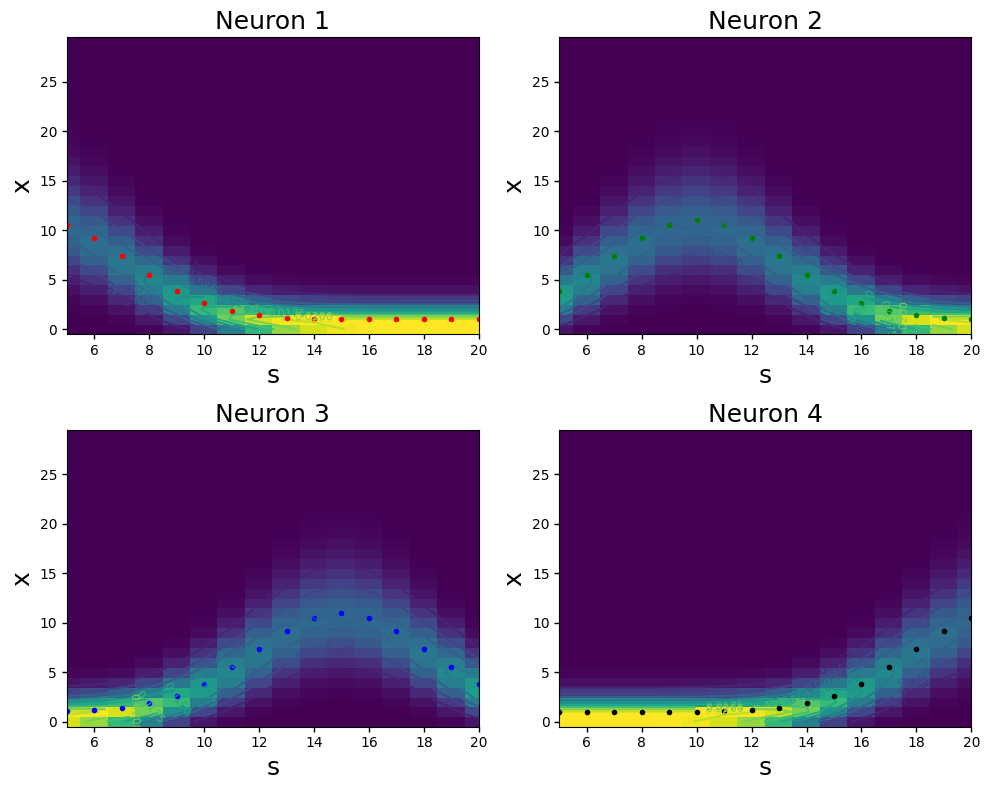

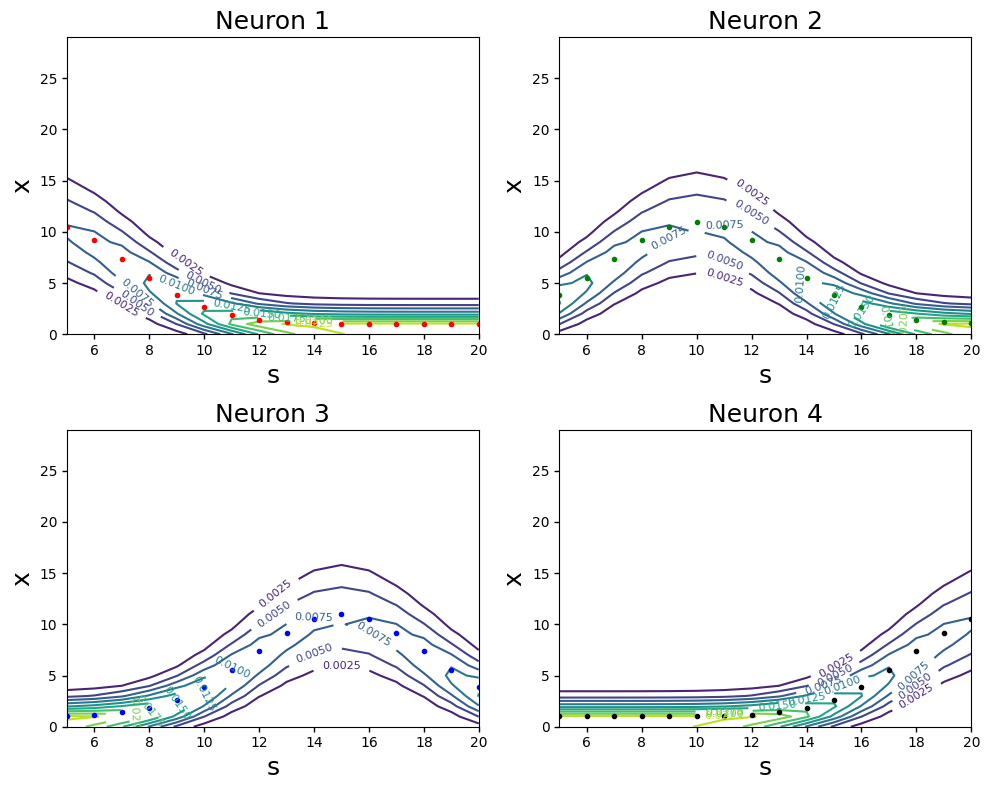

In [ ]:
S_in = np.arange(5,21)
# generate list of potential outputs
x_out = np.arange(0,30)
# given the input and outputs, calculate the joint probability
PN_XandS, EXN_S = RespPDF(S_in, x_out)
# plot the joint probability of x (response) and s (stimulus)
ShowRespPDF(S_in, x_out, PN_XandS, EXN_S, dispImage=True)
ShowRespPDF(S_in, x_out, PN_XandS, EXN_S)

The figure above shows joint probability $P(x,s)$. We see that the contour lines are brightest at the points that line up with a response of 0 on the Y axis. This is because the likelihood of the response being 0 when the input is outside of the tuning range of the neuron is high with little variation. Meanwhile the contour lines near the peak outputs is darker because there is more variation in the responses as the stimulus nears the tuning point of the neuron.

4.0
4.0


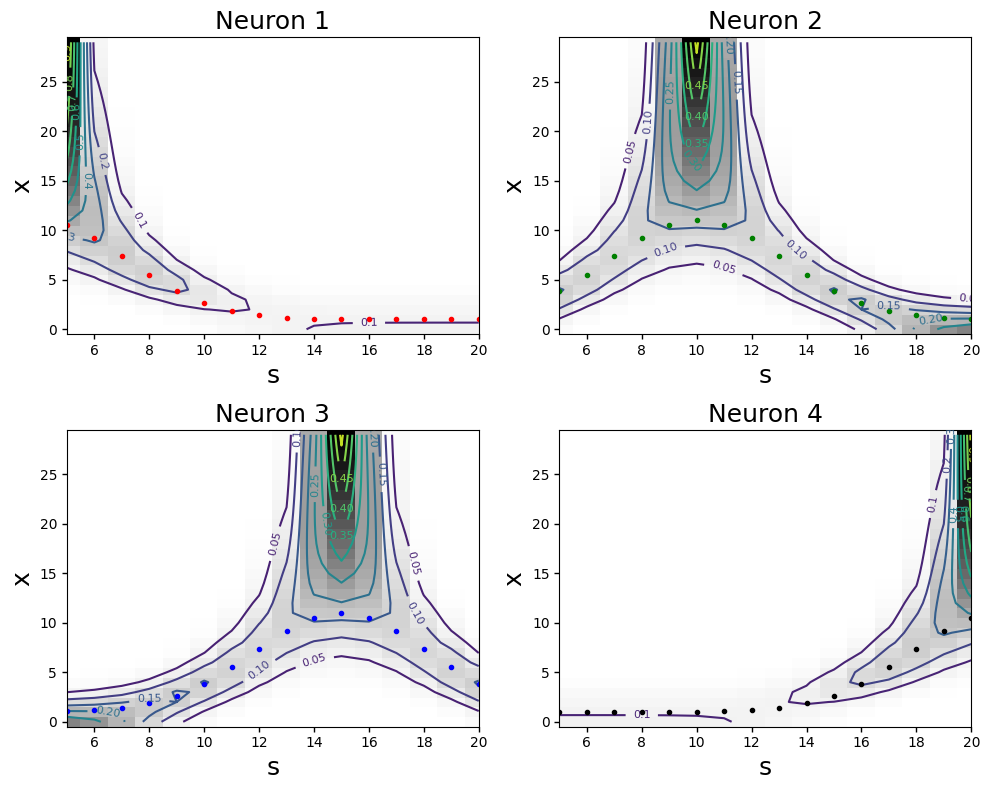

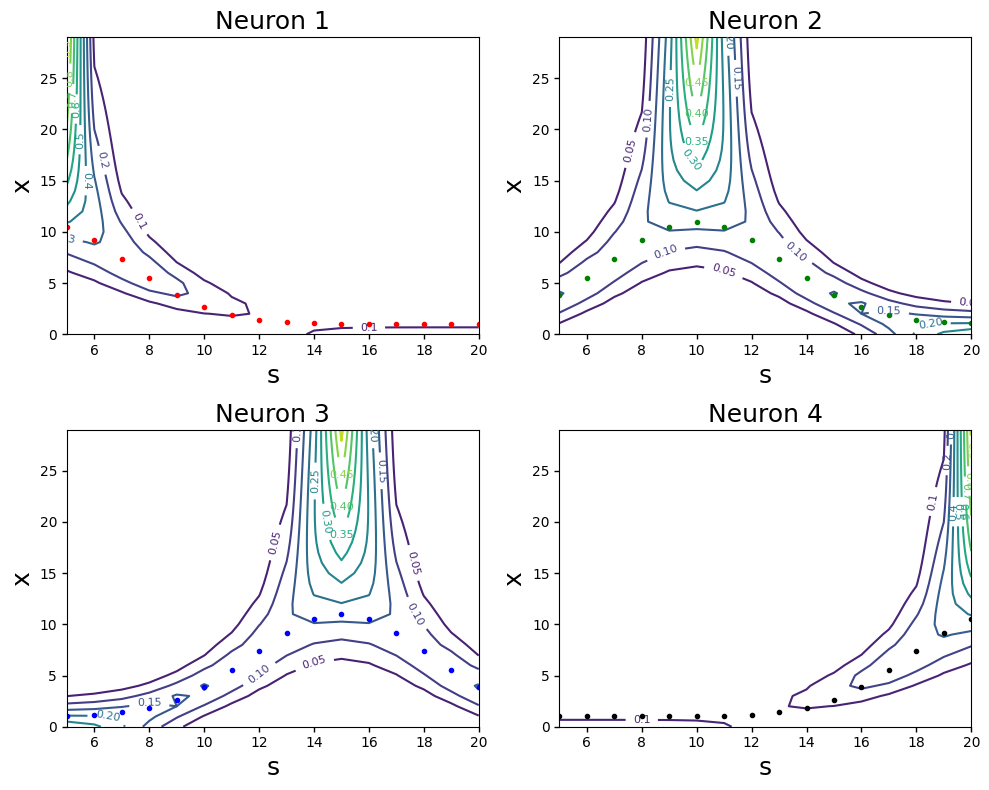

In [ ]:
# given the joint probabilities, calculate the marginal probabilities
# by summing along the last axis, we get the marginal probability of output x_i
# because we have 4 neurons, the marginal probability matrix is [4,n_x]
P_marg_X = np.sum(PN_XandS, axis=2)
print(np.sum(P_marg_X))
# by summing along the second axis, we get the marginal probability of stimulus s_i
# because we have 4 neurons, the marginal probability matrix is [4,n_s]
P_marg_S = np.sum(PN_XandS, axis=1)
print(np.sum(P_marg_S))
# calculate conditional probability of s given x
# conditional probability can be calculated using the Bayes theorem
# P(s|x) = P(x,s)/P(x)
# conditional probability gives a 2 dimensional matrix for each of the 4 neurons
P_s_given_x = np.empty_like(PN_XandS)
for neuron in range(PN_XandS.shape[0]):
    for n_x in range(PN_XandS.shape[2]):
        x = np.divide(PN_XandS[neuron,:,n_x], P_marg_X[neuron,:])
        P_s_given_x[neuron,:,n_x] = np.divide(PN_XandS[neuron,:,n_x], P_marg_X[neuron,:])

# display the conditional likelihood of s given x
ShowRespPDF(S_in, x_out, P_s_given_x, EXN_S, dispImage=True)
ShowRespPDF(S_in, x_out, P_s_given_x, EXN_S, dispImage=False)

The figure above shows the conditional probability $P(s|x)$. This shows that the probability is highest near the tuning range of each neuron, with the maximal likelihood telling us the preferred stimulus of each neuron, with the preferred stimuli being:

$s_{ml}$ for Neuron 1: 5

$s_{ml}$ for Neuron 2: 10

$s_{ml}$ for Neuron 3: 15

$s_{ml}$ for Neuron 4: 20


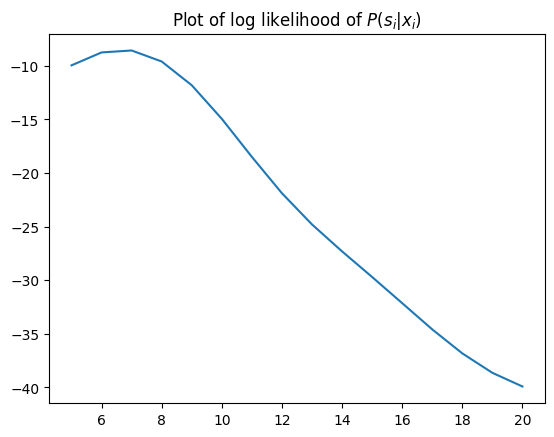

In [ ]:
#%% Assignment II
# given a response vector r_a
r_a = np.array([11, 8, 3, 1])
# compute the joint conditional log-likelihood of different stimuli having caused this response
# create an empty vector to store the relevant conditional probabilities
log_P_s_given_r_a = np.empty([16,4])
for actNeuron in range(r_a.shape[0]):
        # use indexing to find the correct rows for the given responses
        log_P_s_given_r_a[:,actNeuron] = P_s_given_x[actNeuron, r_a[actNeuron], :]
# calculate and sum the log likelihoods
log_P_s_given_r_a = np.log(log_P_s_given_r_a)
log_P_sum_s_given_r_a = np.sum(log_P_s_given_r_a, axis=1)
# test plot for the first response before turning calculation into a function
plt.figure()
plt.plot(S_in, log_P_sum_s_given_r_a)
plt.title('Plot of log likelihood of $P(s_i |x_i )$')
plt.show()

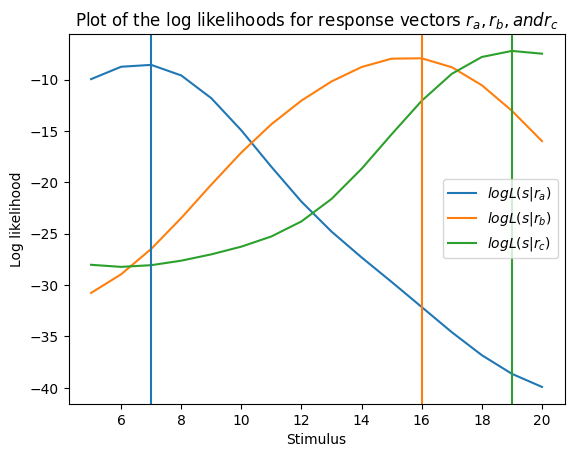

In [ ]:
def calculateLogLikelihoodStimulus(respVector, stimVector, jointConditionalMatrix):
    '''

    Parameters
    ----------
    respVector : int array
        [4,] response vector
    stimVector : int array
        [s_i,] array of stimulus values
    jointConditionalMatrix : float array
        [4,x_i, s_i] matrix of joint conditional probabilities

    Returns
    -------
    logLikelihoodArray : float array
        [s_i,] matrix containing the log likelihood stimulus of a given response
    ML : float
        float value for the maximum likelihood of a given stimulus
    s_ML : int
        int value for the maximum likelihood stimulus given the response vector
    '''
    log_P_s_given_r_a = np.empty([len(stimVector),4])
    for actNeuron in range(respVector.shape[0]):
            log_P_s_given_r_a[:,actNeuron] = jointConditionalMatrix[actNeuron, respVector[actNeuron], :]
    log_P_s_given_r_a = np.log(log_P_s_given_r_a)
    logLikelihoodArray = np.sum(log_P_s_given_r_a, axis=1)
    MLidx = np.argmax(logLikelihoodArray)
    ML = logLikelihoodArray[MLidx]
    s_ML = stimVector[MLidx]
    return logLikelihoodArray, ML, s_ML
# calculate the log likelihood and maximum likelihood stimulus for r_a to confirm function works
r_aLL, _, r_aLLStim, = calculateLogLikelihoodStimulus(r_a, S_in, P_s_given_x)
# calculate LL and ML for r_b and r_c
r_b = np.array([1,4,10,4])
r_c = np.array([2,0,5,8])
r_bLL, _, r_bLLStim = calculateLogLikelihoodStimulus(r_b, S_in, P_s_given_x)
r_cLL, _, r_cLLStim = calculateLogLikelihoodStimulus(r_c, S_in, P_s_given_x)
# plot the three LLs along with vertical lines denoting maximum likelihood stimulus
plt.figure()
plt.plot(S_in, r_aLL, label='$log L(s|r_a)$')
plt.plot(S_in, r_bLL, label='$log L(s|r_b)$')
plt.plot(S_in, r_cLL, label='$log L(s|r_c)$')
plt.axvline(r_aLLStim, color='C0')
plt.axvline(r_bLLStim, color='C1')
plt.axvline(r_cLLStim, color='C2')
plt.legend(loc='center right')
plt.title('Plot of the log likelihoods for response vectors $r_a , r_b , and r_c$')
plt.xlabel('Stimulus')
plt.ylabel('Log likelihood')
plt.show()

This plot shows the sum of the log likelihood of each response vector $r_a$, $r_b$, $r_c$ given a stimulus of $5 \leq s \leq 20$. The plotted line shows the log likelihood for each stimulus, while the vertical lines denote the stimulus that most likely generated the particular response vector.

calculating log likelihood for s=5
calculating log likelihood for s=6
calculating log likelihood for s=7
calculating log likelihood for s=8
calculating log likelihood for s=9
calculating log likelihood for s=10
calculating log likelihood for s=11
calculating log likelihood for s=12
calculating log likelihood for s=13
calculating log likelihood for s=14
calculating log likelihood for s=15
calculating log likelihood for s=16
calculating log likelihood for s=17
calculating log likelihood for s=18
calculating log likelihood for s=19
calculating log likelihood for s=20


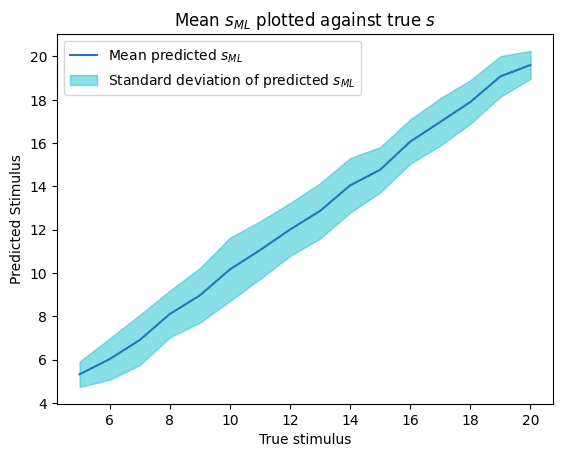

In [ ]:
#%% assignment III
# For each possible stimulus s, with 5≤s≤20, obtain from SensResp4() 100 population responses rk
# From every rk, compute the joint conditional log-likelihood logP(s|rk) and the associated ML estimate sML (i.e., the value of s for which logP(s|rk) is maximal).
# Averaging over the 100 repetitions, compute the average ⟨s_ml⟩ and standard deviation sqrt((s_ml^2) - (s_ml)^2)
# Plot average and standard deviation as a function of the true stimulus s! Are some stimuli encoded better or worse than others?

nInputs = 100
ML_mean = np.empty(16)
ML_std = np.empty(16)
n = 0
for s in range(5,21):
    k = np.empty([1,nInputs])
    k[0,:] = s
    r_k = SensResp4(k)
    print(f"calculating log likelihood for s={s}")
    combinedLL = np.empty([16, nInputs])
    combinedML = np.empty(nInputs)
    combined_sML = np.empty(nInputs)
    for x in range(nInputs):
        combinedLL[:,x], combinedML[x], combined_sML[x] = calculateLogLikelihoodStimulus(r_k[:,x], S_in, P_s_given_x)
    ML_mean[n] = np.mean(combined_sML)
    ML_std[n] = np.std(combined_sML)
    n +=1
ML_std_upper = ML_mean + ML_std
ML_std_lower = ML_mean - ML_std
plt.figure()
plt.plot(S_in, ML_mean, label='Mean predicted $s_{ML}$')
plt.fill_between(S_in, ML_std_lower, ML_std_upper, alpha=0.5, color='C9', label='Standard deviation of predicted $s_{ML}$')
plt.xlabel('True stimulus')
plt.ylabel('Predicted Stimulus')
plt.legend(loc='upper left')
plt.title('Mean $s_{ML}$ plotted against true $s$')
plt.show()

After generating 100 noisy responses for each potential stimulus $5 \leq s \leq 20$, we calculated the mean value and the standard deviation for each stimulus. This shows that the standard deviation tends to be smaller at the preferred stimulus for each neuron and larger outside of the preferred stimulus range for each neuron.